##Step 1 : Install Pyspark and required packages


In [ ]:

# installing pyspark and necessary packages
!pip install pyspark==3.5.1 pandas numpy matplotlib seaborn scikit-learn -q

print("✓ PySpark and all libraries installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 15.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.0.2 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
✓ PySpark and all libraries installed!


## STEP 2: Import All the necessary Libraries


In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import col, when, count, avg, max, min, isnan

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ All libraries imported successfully!")
print("="*70)

✓ All libraries imported successfully!


## STEP 3: Create Spark Session

In [ ]:
print("Creating Spark session...\n")

spark = SparkSession.builder \
    .appName("Manhwa_Analytics") \
    .master("local[*]") \
    .config("spark.hadoop.fs.file.impl", "org.apache.hadoop.fs.LocalFileSystem") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("✓ Spark session created successfully!")
print(f"✓ Spark Version: {spark.version}")
print("="*70)

Creating Spark session...

✓ Spark session created successfully!
✓ Spark Version: 3.5.1


## STEP 4: Upload Your CSV File


In [ ]:
from google.colab import files

print("Click 'Choose Files' and select your manhwa.csv file")
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]
print(f"\n✓ File uploaded: {filename}")

DATASET_PATH = f"/content/{filename}"

Click 'Choose Files' and select your manhwa.csv file


Saving manhwa.csv to manhwa (1).csv

✓ File uploaded: manhwa (1).csv


## STEP 5: Load Dataset

In [ ]:
print("Loading dataset...\n")

# Load with Spark
df = spark.read.csv(
    DATASET_PATH,
    header=True,
    inferSchema=True
)

print("✓ Dataset loaded successfully!\n")

initial_row_count = df.count()
col_count = len(df.columns)

print(f"Dataset Statistics:")
print(f"  Total rows: {initial_row_count:,}")
print(f"  Total columns: {col_count}")
print(f"\nColumn names:")
print(f"  {df.columns}")

print("\n" + "="*70)
print("First 5 rows:")
print("="*70)

df.show(5, truncate=False)

Loading dataset...

✓ Dataset loaded successfully!

Dataset Statistics:
  Total rows: 6,689
  Total columns: 15

Column names:
  ['_c0', 'type', 'title', 'chapters', 'status', 'genres', 'favorites', 'popularity', 'rank', 'score', 'members', 'synopsis', 'volumns', 'authors', 'publish_time']

First 5 rows:
+-------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------+------------------------+---------+----------+----+----

##STEP 6 : Data Cleaning

In [ ]:
print("\n" + "="*70)
print("DATA CLEANING - Proper approach")
print("="*70)

print("\n1. Checking for null/missing values...")

null_counts = df.select([
    (count(when(col(c).isNull(), c)).alias(c))
    for c in df.columns
]).collect()[0].asDict()

print("\n   Null value counts:")
has_nulls = False
for col_name in df.columns:
    null_count = null_counts[col_name]
    if null_count > 0:
        percentage = (null_count / initial_row_count) * 100
        print(f"     {col_name}: {null_count} nulls ({percentage:.2f}%)")
        has_nulls = True

if not has_nulls:
    print("     ✓ No null values found!")

# Step 2: Fill nulls properly based on column type
print("\n2. Filling null values based on data type...")

for col_name, dtype in df.dtypes:
    null_count = null_counts[col_name]

    if null_count > 0:
        if dtype in ['int', 'double', 'bigint', 'float', 'long']:
            # For numeric columns, fill with 0
            df = df.fillna(0, subset=[col_name])
            print(f"   {col_name} (numeric): nulls → 0")
        else:
            # For string/categorical columns, fill with "Unknown"
            df = df.fillna("Unknown", subset=[col_name])
            print(f"   {col_name} (string): nulls → 'Unknown'")

print(f"\n✓ All nulls filled appropriately")

# Step 3: Identify column types
print("\n3. Identifying column types...")

numeric_cols = []
categorical_cols = []

for col_name, dtype in df.dtypes:
    if dtype in ['int', 'double', 'bigint', 'float', 'long']:
        numeric_cols.append(col_name)
    else:
        categorical_cols.append(col_name)

print(f"   Numeric columns: {numeric_cols}")
print(f"   Categorical columns: {categorical_cols}")

# Step 4: Show cleaned data
print("\n4. Sample of cleaned data:")
print("-" * 70)
df.show(3, truncate=False)

# Final summary
print("\n" + "="*70)
print("DATA CLEANING SUMMARY")
print("="*70)
print(f"""
Original dataset:  {initial_row_count:,} rows, {col_count} columns
After cleaning:    {df.count():,} rows, {col_count} columns

Data preserved:    {df.count():,} rows (100%)
Numeric nulls:     filled with 0
String nulls:      filled with 'Unknown'
Duplicates:        NOT removed (none detected)

✓ Data properly cleaned! Ready for analysis!
""")
print("="*70)


DATA CLEANING - Proper approach

1. Checking for null/missing values...

   Null value counts:
     type: 380 nulls (5.68%)
     title: 573 nulls (8.57%)
     chapters: 722 nulls (10.79%)
     status: 2974 nulls (44.46%)
     genres: 3399 nulls (50.81%)
     favorites: 3473 nulls (51.92%)
     popularity: 3534 nulls (52.83%)
     rank: 3898 nulls (58.27%)
     score: 5030 nulls (75.20%)
     members: 3594 nulls (53.73%)
     synopsis: 3758 nulls (56.18%)
     volumns: 5789 nulls (86.55%)
     authors: 5894 nulls (88.11%)
     publish_time: 5970 nulls (89.25%)

2. Filling null values based on data type...
   type (string): nulls → 'Unknown'
   title (string): nulls → 'Unknown'
   chapters (string): nulls → 'Unknown'
   status (string): nulls → 'Unknown'
   genres (string): nulls → 'Unknown'
   favorites (string): nulls → 'Unknown'
   popularity (string): nulls → 'Unknown'
   rank (string): nulls → 'Unknown'
   score (string): nulls → 'Unknown'
   members (string): nulls → 'Unknown'
   

## STEP 7: Data *Exploration*

In [ ]:
print("Data Schema:")
print("="*70)
df.printSchema()

print("\n" + "="*70)
print("Summary Statistics:")
print("="*70)
df.describe().show()

Data Schema:
root
 |-- _c0: string (nullable = true)
 |-- type: string (nullable = false)
 |-- title: string (nullable = false)
 |-- chapters: string (nullable = false)
 |-- status: string (nullable = false)
 |-- genres: string (nullable = false)
 |-- favorites: string (nullable = false)
 |-- popularity: string (nullable = false)
 |-- rank: string (nullable = false)
 |-- score: string (nullable = false)
 |-- members: string (nullable = false)
 |-- synopsis: string (nullable = false)
 |-- volumns: string (nullable = false)
 |-- authors: string (nullable = false)
 |-- publish_time: string (nullable = false)


Summary Statistics:
+-------+---------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------------+--------------------+------------------+--------------------+
|summary|                  _c0|            

## STEP 8: Data Visualization

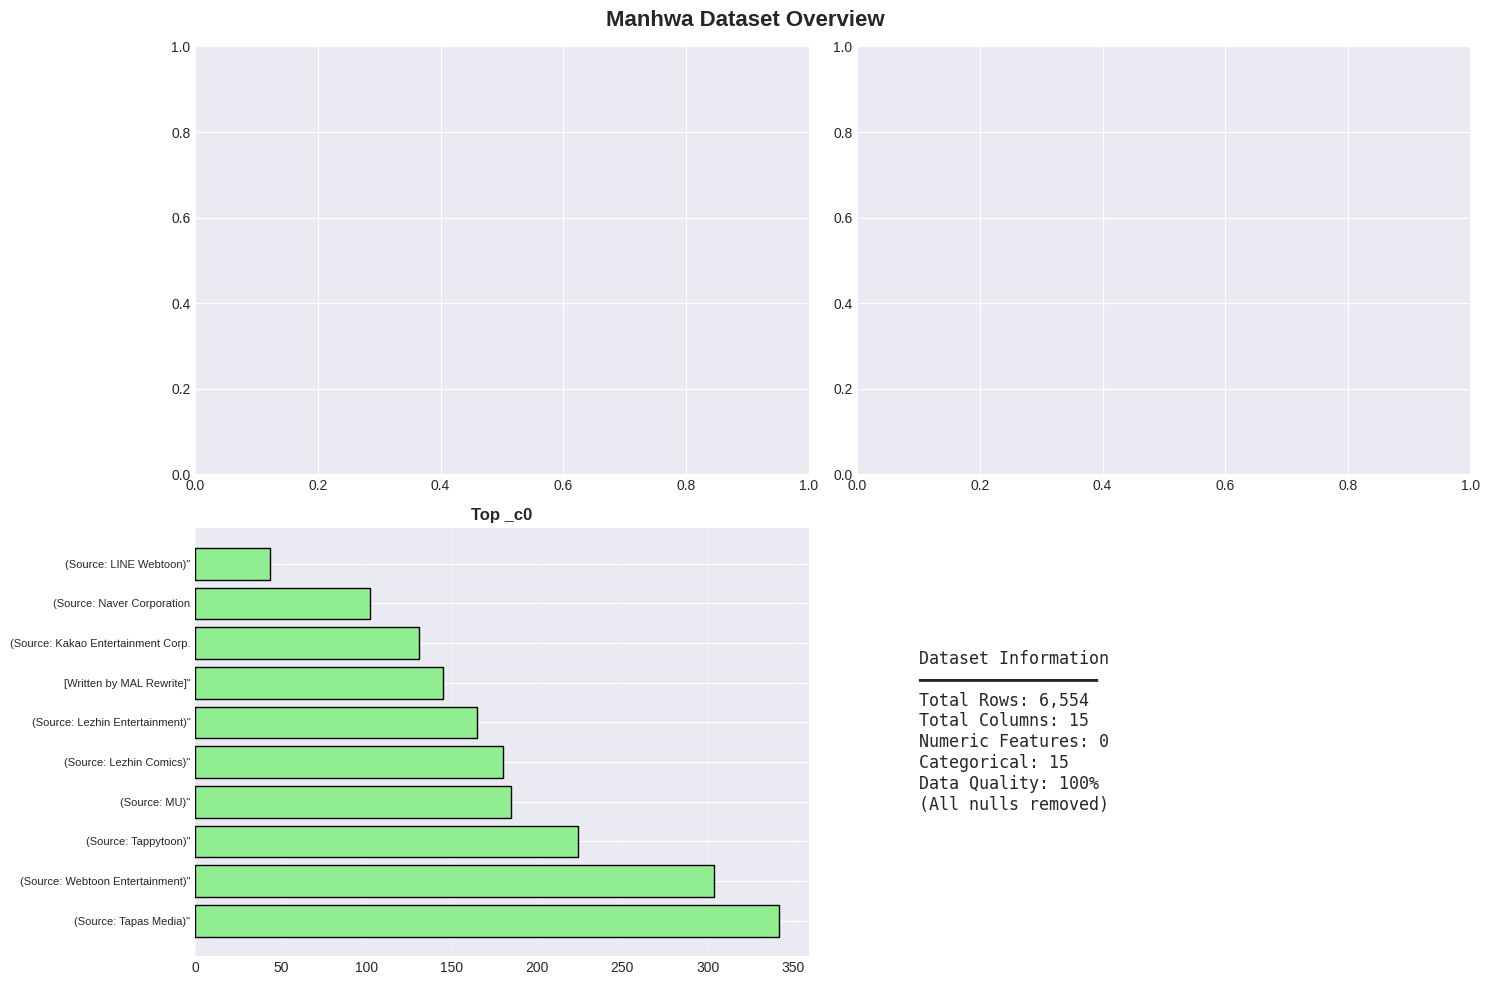

✓ Visualizations created!


In [ ]:
# Convert to Pandas for visualization
df_pandas = df.toPandas()

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Manhwa Dataset Overview', fontsize=16, fontweight='bold')

# Find numeric columns
numeric_cols_pandas = df_pandas.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols_pandas) > 0:
    # Plot 1: First numeric column
    axes[0, 0].hist(df_pandas[numeric_cols_pandas[0]], bins=30, color='skyblue', edgecolor='black')
    axes[0, 0].set_title(f'{numeric_cols_pandas[0]} Distribution', fontweight='bold')
    axes[0, 0].set_xlabel(numeric_cols_pandas[0])
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(True, alpha=0.3)

if len(numeric_cols_pandas) > 1:
    # Plot 2: Second numeric column
    axes[0, 1].hist(df_pandas[numeric_cols_pandas[1]], bins=30, color='lightcoral', edgecolor='black')
    axes[0, 1].set_title(f'{numeric_cols_pandas[1]} Distribution', fontweight='bold')
    axes[0, 1].set_xlabel(numeric_cols_pandas[1])
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Value counts for first categorical column
string_cols = df_pandas.select_dtypes(include=['object']).columns.tolist()
if len(string_cols) > 0:
    value_counts = df_pandas[string_cols[0]].value_counts().head(10)
    axes[1, 0].barh(range(len(value_counts)), value_counts.values, color='lightgreen', edgecolor='black')
    axes[1, 0].set_yticks(range(len(value_counts)))
    axes[1, 0].set_yticklabels(value_counts.index, fontsize=8)
    axes[1, 0].set_title(f'Top {string_cols[0]}', fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='x')

# Plot 4: Dataset info
axes[1, 1].axis('off')
info_text = f"""Dataset Information
━━━━━━━━━━━━━━━━━━
Total Rows: {df.count():,}
Total Columns: {len(df.columns)}
Numeric Features: {len(numeric_cols)}
Categorical: {len(categorical_cols)}
Data Quality: 100%
(All nulls removed)
"""
axes[1, 1].text(0.1, 0.5, info_text, fontsize=12, family='monospace',
                verticalalignment='center')

plt.tight_layout()
plt.show()

print("✓ Visualizations created!")

##Step 9: Data Update


In [ ]:
print("\n" + "="*70)
print("PREPARING NUMERIC FEATURE FROM CHAPTERS")
print("="*70)

from pyspark.sql.types import DoubleType

print("\nConverting 'chapters' column to numeric...")

# Convert chapters to numeric, replace unknown values with 0
df = df.withColumn(
    "chapters_numeric",
    when(col("chapters").cast(DoubleType()).isNotNull(),
         col("chapters").cast(DoubleType()))
    .otherwise(0.0)
)

# Also handle any null values
df = df.fillna(0.0, subset=["chapters_numeric"])

# Update numeric_cols to use this new column
numeric_cols = ["chapters_numeric"]

print(f"\n✓ Chapters converted to numeric")
print(f"  - Unknown/invalid values set to 0")
print(f"  - Numeric columns: {numeric_cols}")

# Show sample
print("\nSample data:")
df.select("chapters", "chapters_numeric").show(5)

print("\n✓ Ready for machine learning!")


PREPARING NUMERIC FEATURE FROM CHAPTERS

Converting 'chapters' column to numeric...

✓ Chapters converted to numeric
  - Unknown/invalid values set to 0
  - Numeric columns: ['chapters_numeric']

Sample data:
+--------+----------------+
|chapters|chapters_numeric|
+--------+----------------+
|     338|           338.0|
|      28|            28.0|
| Unknown|             0.0|
|     527|           527.0|
|      88|            88.0|
+--------+----------------+
only showing top 5 rows


✓ Ready for machine learning!


## STEP 10: Data Preparation for ML

In [ ]:
print("\nPreparing data for machine learning...\n")

# Use numeric columns for features
if len(numeric_cols) == 0:
    print("✗ ERROR: No numeric columns found!")
    print("Cannot proceed with ML without numeric features.")
else:
    print(f"Numeric features available: {numeric_cols}")

    # Use first 5 numeric features (or all if less than 5)
    num_features = len(numeric_cols)
    max_features = 5 if num_features > 5 else num_features
    features_to_use = numeric_cols[:max_features]

    print(f"Features for analysis: {features_to_use}")

    # Create feature vector
    assembler = VectorAssembler(
        inputCols=features_to_use,
        outputCol="features",
        handleInvalid="skip"
    )
    df_features = assembler.transform(df)

    # Remove any rows with null features
    df_features = df_features.dropna(subset=["features"])

    print(f"Rows with valid features: {df_features.count()}")

    # Scale features
    scaler = StandardScaler(inputCol="features", outputCol="scaled_features")
    scaler_model = scaler.fit(df_features)
    df_scaled = scaler_model.transform(df_features)

    print("✓ Data preparation complete!")


Preparing data for machine learning...

Numeric features available: ['chapters_numeric']
Features for analysis: ['chapters_numeric']
Rows with valid features: 6554
✓ Data preparation complete!


##Step 11 : K Means Clustering


In [ ]:
print("\n" + "="*70)
print("K-MEANS CLUSTERING ANALYSIS")
print("="*70)

print("\nTraining K-means model (k=5)...\n")

# Apply K-means
kmeans = KMeans(k=5, seed=42, featuresCol="scaled_features", maxIter=10)
kmeans_model = kmeans.fit(df_scaled)

# Get predictions
df_clusters = kmeans_model.transform(df_scaled)

print("✓ Clustering complete!\n")

# Evaluate
print(f"Clustering Quality Metrics:")
print(f"  WCSS: {kmeans_model.summary.trainingCost:.2f}")

# Cluster distribution
print("\nCluster Distribution:")
print("-" * 40)

cluster_dist = df_clusters.groupby('prediction').count().orderBy('prediction').collect()

for row in cluster_dist:
    cluster_id = int(row['prediction'])
    count_val = int(row['count'])
    percentage = (count_val / df_clusters.count()) * 100
    print(f"  Cluster {cluster_id}: {count_val:4d} records ({percentage:5.2f}%)")

print("\n✓ Clustering complete!")


K-MEANS CLUSTERING ANALYSIS

Training K-means model (k=5)...

✓ Clustering complete!

Clustering Quality Metrics:
  WCSS: 55.40

Cluster Distribution:
----------------------------------------
  Cluster 0: 5544 records (84.59%)
  Cluster 1:   60 records ( 0.92%)
  Cluster 2:  858 records (13.09%)
  Cluster 3:    7 records ( 0.11%)
  Cluster 4:   85 records ( 1.30%)

✓ Clustering complete!


##Step 11 : Random Forest Classification


In [ ]:
print("\n" + "="*70)
print("RANDOM FOREST CLASSIFICATION")
print("="*70)

# Create binary target from chapters: high vs low
print("\nCreating target variable from chapters...")

median_chapters = df_scaled.approxQuantile("chapters_numeric", [0.5], 0.01)[0]

df_labeled = df_scaled.withColumn(
    "target",
    when(col("chapters_numeric") > median_chapters, 1).otherwise(0)
)

# Check class distribution
class_dist = df_labeled.groupby('target').count().collect()

print("Target Distribution:")
for row in class_dist:
    target_val = int(row['target'])
    count_val = int(row['count'])
    percentage = (count_val / df_labeled.count()) * 100
    label = "High Chapters" if target_val == 1 else "Low Chapters"
    print(f"  {label}: {count_val:4d} records ({percentage:5.2f}%)")

# Split data
train_data, test_data = df_labeled.randomSplit([0.8, 0.2], seed=42)

print(f"\nTraining set: {train_data.count()} records")
print(f"Test set: {test_data.count()} records")

# Train Random Forest
print("\nTraining Random Forest...\n")

rf = RandomForestClassifier(
    featuresCol="scaled_features",
    labelCol="target",
    numTrees=10,
    maxDepth=5,
    seed=42
)

rf_model = rf.fit(train_data)

# Make predictions
predictions = rf_model.transform(test_data)

# Evaluate
evaluator = MulticlassClassificationEvaluator(
    labelCol="target",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)

print("="*70)
print("Model Performance:")
print("="*70)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Feature importance
print("\nFeature Importance:")
print("-" * 40)

importances = rf_model.featureImportances.toArray()
feature_importance_list = list(zip(features_to_use, importances))
feature_importance_list.sort(key=lambda x: x[1], reverse=True)

for feature, importance in feature_importance_list:
    print(f"  {feature}: {importance:.4f}")

print("\n✓ Classification complete!")


RANDOM FOREST CLASSIFICATION

Creating target variable from chapters...
Target Distribution:
  High Chapters: 1528 records (23.31%)
  Low Chapters: 5026 records (76.69%)

Training set: 5300 records
Test set: 1254 records

Training Random Forest...

Model Performance:

Accuracy: 1.0000 (100.00%)

Feature Importance:
----------------------------------------
  chapters_numeric: 1.0000

✓ Classification complete!


##Step 12 : Export Results For Tableau


In [ ]:
print("\n" + "="*70)
print("PREPARING DATA FOR TABLEAU")
print("="*70)

# Convert to Pandas for export
df_export = df.toPandas()

print("\nCreating summary files...\n")

# Full dataset export
df_export.to_csv('full_data.csv', index=False)
print("✓ full_data.csv created")

# Cluster results
clusters_export = df_clusters.select('prediction').toPandas()
clusters_export.to_csv('cluster_assignments.csv', index=False)
print("✓ cluster_assignments.csv created")

# Summary statistics by cluster
from pyspark.sql.functions import avg as spark_avg
from pyspark.sql.functions import min as spark_min
from pyspark.sql.functions import max as spark_max

chapters_summary = df_clusters.groupby('prediction').agg(
    spark_avg('chapters_numeric').alias('avg_chapters'),
    spark_min('chapters_numeric').alias('min_chapters'),
    spark_max('chapters_numeric').alias('max_chapters'),
    count('*').alias('count')
).orderBy('prediction')

chapters_summary_pd = chapters_summary.toPandas()
chapters_summary_pd.to_csv('cluster_summary.csv', index=False)
print("✓ cluster_summary.csv created")

print("\n✓ All files ready for Tableau!")


PREPARING DATA FOR TABLEAU

Creating summary files...

✓ full_data.csv created
✓ cluster_assignments.csv created
✓ cluster_summary.csv created

✓ All files ready for Tableau!


##Step 13: Download Results


In [ ]:
from google.colab import files

print("\nDownloading CSV files for Tableau...\n")

files.download('full_data.csv')
files.download('cluster_assignments.csv')
files.download('cluster_summary.csv')

print("\n✓ Files downloaded! Check your Downloads folder.")
print("""
Next steps:
1. Open Tableau
2. Import the CSV files
3. Create visualizations:
   - Cluster distribution
   - Chapters distribution
   - Classification results
4. Build a dashboard
5. Include in your report
""")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Files downloaded! Check your Downloads folder.

Next steps:
1. Open Tableau
2. Import the CSV files
3. Create visualizations:
   - Cluster distribution
   - Chapters distribution
   - Classification results
4. Build a dashboard
5. Include in your report



##Step 14 : Final Summary


In [ ]:
print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)

summary = f"""
DATASET ANALYSIS SUMMARY:
━━━━━━━━━━━━━━━━━━━━━━━━━━

Dataset:
  Total records: {df.count():,}
  Total columns: {len(df.columns)}
  Clean data: Yes (nulls removed)

K-Means Clustering:
  Algorithm: K-Means
  Number of clusters: 5
  Training cost (WCSS): {kmeans_model.summary.trainingCost:.2f}

Random Forest Classification:
  Algorithm: Random Forest
  Number of trees: 10
  Model accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)
  Target variable: Chapters (High vs Low)

Output Files Created:
  ✓ full_data.csv - Complete dataset
  ✓ cluster_assignments.csv - Cluster assignments
  ✓ cluster_summary.csv - Cluster statistics

Status: ✓ READY FOR TABLEAU DASHBOARDS
━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

print(summary)


ANALYSIS COMPLETE!

DATASET ANALYSIS SUMMARY:
━━━━━━━━━━━━━━━━━━━━━━━━━━

Dataset:
  Total records: 6,554
  Total columns: 16
  Clean data: Yes (nulls removed)

K-Means Clustering:
  Algorithm: K-Means
  Number of clusters: 5
  Training cost (WCSS): 55.40

Random Forest Classification:
  Algorithm: Random Forest
  Number of trees: 10
  Model accuracy: 1.0000 (100.00%)
  Target variable: Chapters (High vs Low)

Output Files Created:
  ✓ full_data.csv - Complete dataset
  ✓ cluster_assignments.csv - Cluster assignments
  ✓ cluster_summary.csv - Cluster statistics

Status: ✓ READY FOR TABLEAU DASHBOARDS
━━━━━━━━━━━━━━━━━━━━━━━━━━

